In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib as mpl

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

In [4]:
# 导入所需的库
# 加载IMDB数据集
(train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(num_words=10000, index_from=3)

# 打印数据集基本信息
print('训练数据集样本数:', len(train_data))
print('测试数据集样本数:', len(test_data))
print('训练数据集第一个样本的长度:', len(train_data[0]))
print('测试数据集第一个样本的长度:', len(test_data[0]))
# 查看训练集第一个样本的词索引序列
print('训练集第一个样本的词索引序列:', train_data[0])

# 获取词索引映射字典
word_index = keras.datasets.imdb.get_word_index()

# 添加特殊字符的索引
word_index = {k:(v+3) for k,v in word_index.items()}
word_index["<PAD>"] = 0  # 填充标记
word_index["<BOS>"] = 1  # 句子开始标记
word_index["<UNK>"] = 2  # 未知词标记
word_index["<EOS>"] = 3  # 句子结束标记
# 创建反向映射，用于将索引转换回单词
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# 定义函数将索引序列转换为文本
def decode_review(text):
    return ' '.join([reverse_word_index.get(i, '?') for i in text])

# 打印第一条评论的原文
print('第一条评论原文:', decode_review(train_data[0]))

训练数据集样本数: 25000
测试数据集样本数: 25000
训练数据集第一个样本的长度: 218
测试数据集第一个样本的长度: 68
训练集第一个样本的词索引序列: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15

In [6]:
reverse_word_index[5]

'and'

In [7]:
word_index['the']

4

In [8]:
train_data[1]

[1,
 194,
 1153,
 194,
 8255,
 78,
 228,
 5,
 6,
 1463,
 4369,
 5012,
 134,
 26,
 4,
 715,
 8,
 118,
 1634,
 14,
 394,
 20,
 13,
 119,
 954,
 189,
 102,
 5,
 207,
 110,
 3103,
 21,
 14,
 69,
 188,
 8,
 30,
 23,
 7,
 4,
 249,
 126,
 93,
 4,
 114,
 9,
 2300,
 1523,
 5,
 647,
 4,
 116,
 9,
 35,
 8163,
 4,
 229,
 9,
 340,
 1322,
 4,
 118,
 9,
 4,
 130,
 4901,
 19,
 4,
 1002,
 5,
 89,
 29,
 952,
 46,
 37,
 4,
 455,
 9,
 45,
 43,
 38,
 1543,
 1905,
 398,
 4,
 1649,
 26,
 6853,
 5,
 163,
 11,
 3215,
 2,
 4,
 1153,
 9,
 194,
 775,
 7,
 8255,
 2,
 349,
 2637,
 148,
 605,
 2,
 8003,
 15,
 123,
 125,
 68,
 2,
 6853,
 15,
 349,
 165,
 4362,
 98,
 5,
 4,
 228,
 9,
 43,
 2,
 1157,
 15,
 299,
 120,
 5,
 120,
 174,
 11,
 220,
 175,
 136,
 50,
 9,
 4373,
 228,
 8255,
 5,
 2,
 656,
 245,
 2350,
 5,
 4,
 9837,
 131,
 152,
 491,
 18,
 2,
 32,
 7464,
 1212,
 14,
 9,
 6,
 371,
 78,
 22,
 625,
 64,
 1382,
 9,
 8,
 168,
 145,
 23,
 4,
 1690,
 15,
 16,
 4,
 1355,
 5,
 28,
 6,
 52,
 154,
 462,
 33,
 89,
 78,
 2

In [10]:
# 将测试集划分为验证集和测试集
validation_size = 10000  # 验证集大小

# 从测试集中分离出验证集
x_val = test_data[:validation_size]
y_val = test_labels[:validation_size]

# 剩余部分作为测试集
x_test = test_data[validation_size:]
y_test = test_labels[validation_size:]

# 打印划分后的数据集大小
print('验证集样本数:', len(x_val))
print('测试集样本数:', len(x_test))
print('验证集标签数:', len(y_val))
print('测试集标签数:', len(y_test))


验证集样本数: 10000
测试集样本数: 15000
验证集标签数: 10000
测试集标签数: 15000


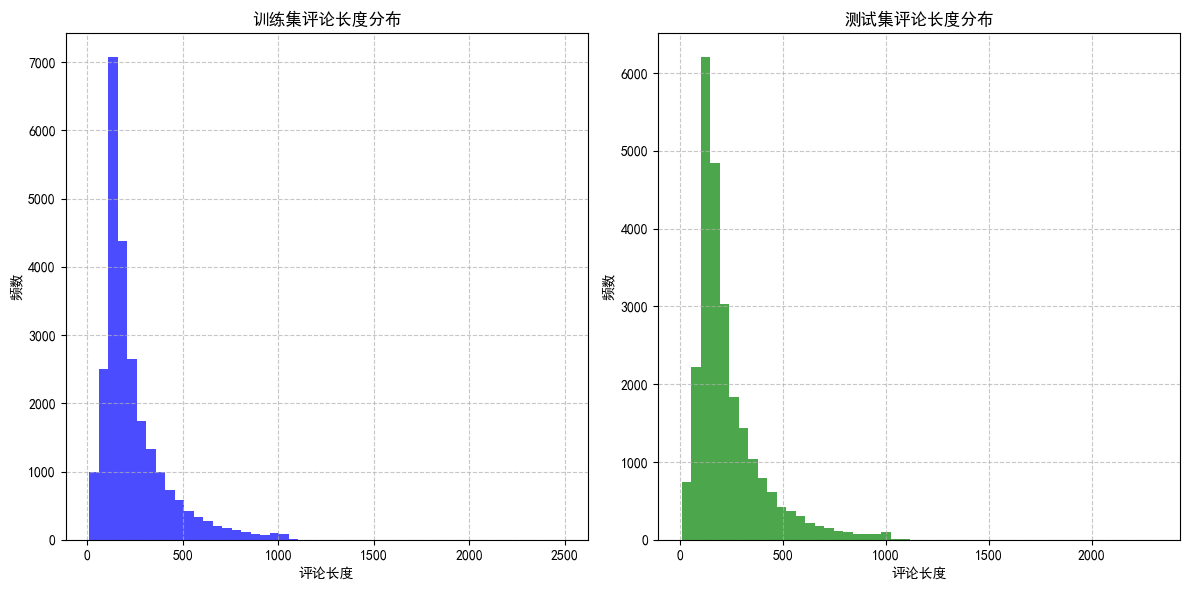

训练集评论长度: 最小值=11, 最大值=2494, 平均值=238.7, 中位数=178.0
测试集评论长度: 最小值=7, 最大值=2315, 平均值=230.8, 中位数=174.0


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 计算训练集中评论的长度
train_lengths = [len(x) for x in train_data]
test_lengths = [len(x) for x in test_data]

plt.figure(figsize=(12, 6))

# 绘制训练集评论长度的直方图
plt.subplot(1, 2, 1)
plt.hist(train_lengths, bins=50, alpha=0.7, color='blue')
plt.xlabel('评论长度')
plt.ylabel('频数')
plt.title('训练集评论长度分布')
plt.grid(True, linestyle='--', alpha=0.7)

# 绘制测试集评论长度的直方图
plt.subplot(1, 2, 2)
plt.hist(test_lengths, bins=50, alpha=0.7, color='green')
plt.xlabel('评论长度')
plt.ylabel('频数')
plt.title('测试集评论长度分布')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 打印一些统计信息
print(f"训练集评论长度: 最小值={min(train_lengths)}, 最大值={max(train_lengths)}, 平均值={np.mean(train_lengths):.1f}, 中位数={np.median(train_lengths)}")
print(f"测试集评论长度: 最小值={min(test_lengths)}, 最大值={max(test_lengths)}, 平均值={np.mean(test_lengths):.1f}, 中位数={np.median(test_lengths)}")


In [15]:
raw_text = ["hello world".split(), "tokenize text datas with batch".split(), "this is a test".split()]
raw_text

[['hello', 'world'],
 ['tokenize', 'text', 'datas', 'with', 'batch'],
 ['this', 'is', 'a', 'test']]

In [16]:
import numpy as np

class Tokenizer:
    def __init__(self, word_index, reverse_word_index):
        """
        初始化Tokenizer类
        
        参数:
        - word_index: 词到索引的映射字典
        - reverse_word_index: 索引到词的映射字典
        """
        self.word_index = word_index
        self.reverse_word_index = reverse_word_index
        self.pad_token = 0  # <PAD> 填充标记
        self.start_token = 1  # <START> 开始标记
        self.unk_token = 2  # <UNK> 未知词标记
        self.end_token = 3  # <END> 结束标记
    
    def encode(self, texts, maxlen=None, padding='post', truncating='post', add_start=False, add_end=False):
        """
        将文本序列转换为数字序列
        
        参数:
        - texts: 文本列表，每个元素是一个词列表
        - maxlen: 序列最大长度，如果为None则使用最长序列的长度
        - padding: 'pre'或'post'，表示在序列前或后填充
        - truncating: 'pre'或'post'，表示从序列前或后截断
        - add_start: 是否添加开始标记
        - add_end: 是否添加结束标记
        
        返回:
        - 编码后的序列
        """
        result = [] # 编码后的序列，存储整个batch的序列
        
        # 计算需要的序列长度
        batch_max_len = max([len(seq) for seq in texts]) # batch内最长序列长度
        if add_start:
            batch_max_len += 1  # 如果添加开始标记，长度加1
        if add_end:
            batch_max_len += 1  # 如果添加结束标记，长度加1
            
        # 如果maxlen为None或者batch内最大长度小于maxlen，使用batch内最大长度
        if maxlen is None or batch_max_len < maxlen:
            maxlen = batch_max_len
        
        for text in texts:
            sequence = []
            
            # 添加开始标记
            if add_start:
                sequence.append(self.start_token)
            
            # 将词转换为索引
            for word in text:
                sequence.append(self.word_index.get(word, self.unk_token))  # 如果词不在词典中，使用未知词标记
            
            # 添加结束标记
            if add_end:
                sequence.append(self.end_token)
            
            # 截断序列
            if len(sequence) > maxlen:
                if truncating == 'pre':
                    sequence = sequence[-maxlen:]  # 从前面截断
                else:  # truncating == 'post'
                    sequence = sequence[:maxlen]  # 从后面截断
            
            # 填充序列
            pad_length = maxlen - len(sequence)
            if pad_length > 0:
                if padding == 'pre':
                    sequence = [self.pad_token] * pad_length + sequence  # 在前面填充
                else:  # padding == 'post'
                    sequence = sequence + [self.pad_token] * pad_length  # 在后面填充
            
            result.append(sequence)
        
        return np.array(result)  # 转换为numpy数组返回
    
    def decode(self, sequences):
        """
        将数字序列转换回文本
        
        参数:
        - sequences: 数字序列列表
        
        返回:
        - 解码后的文本列表
        """
        result = []
        for sequence in sequences:
            words = []
            for idx in sequence:
                if idx == self.pad_token:
                    continue  # 跳过填充标记
                word = self.reverse_word_index.get(idx, '?')  # 如果索引不存在，用'?'代替
                # if word not in ['[PAD]', '[BOS]', '[UNK]', '[EOS]']:
                words.append(word)
            result.append(' '.join(words))  # 将词列表连接成字符串
        return result

# 创建Tokenizer实例
tokenizer = Tokenizer(word_index, reverse_word_index)

# 测试编码
encoded = tokenizer.encode(raw_text, maxlen=500, padding='post', add_start=True, add_end=True)
print("编码后的序列:")
print(encoded)

# 测试解码
decoded = tokenizer.decode(encoded)
print("\n解码后的文本:")
print(decoded)


编码后的序列:
[[    1  4825   182     3     0     0     0]
 [    1     2  3004     2    19 19233     3]
 [    1    14     9     6  2181     3     0]]

解码后的文本:
['<BOS> hello world <EOS>', '<BOS> <UNK> text <UNK> with batch <EOS>', '<BOS> this is a test <EOS>']


In [17]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split

class TextDataset(Dataset):
    """
    文本数据集类
    """
    def __init__(self, sequences, tokenizer, labels=None):
        """
        初始化文本数据集
        
        参数:
        - sequences: 编码后的序列
        - tokenizer: 分词器实例
        - labels: 标签（可选）
        """
        # 将编码序列解码为文本
        self.texts = tokenizer.decode(sequences)
        self.tokenizer = tokenizer
        self.labels = labels
    
    def __len__(self):
        """
        返回数据集大小
        """
        return len(self.texts)
    
    def __getitem__(self, idx):
        """
        获取指定索引的样本
        
        参数:
        - idx: 索引
        
        返回:
        - 样本（文本和标签，如果有的话）
        """
        if self.labels is not None:
            return self.texts[idx], self.labels[idx]  # 返回文本和对应的标签
        return self.texts[idx]  # 如果没有标签，只返回文本

def collate_fn(batch, tokenizer, maxlen=500):
    """
    自定义批处理函数，用于在加载数据时进行编码
    
    参数:
    - batch: 批次数据
    - tokenizer: 分词器实例
    - maxlen: 最大序列长度
    
    返回:
    - 编码后的序列和标签（如果有的话）
    """
    if isinstance(batch[0], tuple):
        # print(batch)
        # 如果批次包含标签
        text_list = [item[0].split() for item in batch]  #batch是128样本，每个样本类型是元组，第一个元素是文本，第二个元素是标签
        label_list = [item[1] for item in batch]  # 提取所有样本的标签
        # print(text_list)
        encoded = tokenizer.encode(text_list, maxlen=maxlen, padding='post', add_start=False, add_end=True)  # 对文本进行编码
        sequences = torch.tensor(encoded, dtype=torch.long)  # 将编码后的序列转换为张量
        labels = torch.tensor(label_list, dtype=torch.float).view(-1, 1)  # 将标签reshape为二维 [batch_size, 1]
        return sequences, labels  # 返回编码后的序列和标签
    else:
        # 如果批次只有文本
        text_list = [item.split() for item in batch]  # 将文本分割成单词列表
        encoded = tokenizer.encode(text_list, maxlen=maxlen, padding='post', add_start=False, add_end=True)  # 对文本进行编码
        sequences = torch.tensor(encoded, dtype=torch.long)  # 将编码后的序列转换为张量
        return sequences  # 只返回编码后的序列

# 示例：创建数据集和数据加载器
# 假设我们有训练、验证和测试数据
# 创建对应的数据集
train_dataset = TextDataset(train_data, tokenizer, train_labels)  # 创建训练数据集
val_dataset = TextDataset(x_val, tokenizer, y_val)  # 创建验证数据集
test_dataset = TextDataset(x_test, tokenizer, y_test)  # 创建测试数据集

# 创建数据加载器
batch_size = 64  # 设置批次大小
train_dataloader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,  # 训练时打乱数据
    collate_fn=lambda batch: collate_fn(batch, tokenizer)  # 使用自定义的批处理函数
)
val_dataloader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,  # 验证时不需要打乱数据
    collate_fn=lambda batch: collate_fn(batch, tokenizer)  # 使用自定义的批处理函数
)
test_dataloader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,  # 测试时不需要打乱数据
    collate_fn=lambda batch: collate_fn(batch, tokenizer)  # 使用自定义的批处理函数
)

# 打印数据集和数据加载器信息
print(f"训练集大小: {len(train_dataset)}")  # 输出训练集样本数量
print(f"验证集大小: {len(val_dataset)}")  # 输出验证集样本数量
print(f"测试集大小: {len(test_dataset)}")  # 输出测试集样本数量

train_dataset[0:3]  # 查看训练集的前三个样本


训练集大小: 25000
验证集大小: 10000
测试集大小: 15000


(["<BOS> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for wh

In [18]:
# 示例：遍历训练数据加载器
print("\n训练数据加载器示例:")
for i, (batch_sequences, batch_labels) in enumerate(train_dataloader):
    print(f"批次 {i+1}:")
    print(f"序列形状: {batch_sequences.shape}")
    print(f"标签形状: {batch_labels.shape}")
    if i == 0:  # 只打印第一个批次
        break
batch_sequences


训练数据加载器示例:
批次 1:
序列形状: torch.Size([64, 500])
标签形状: torch.Size([64, 1])


tensor([[   1,  854,   13,  ...,    0,    0,    0],
        [   1, 4078, 1225,  ...,    4, 1529,  139],
        [   1, 5040,   16,  ...,    0,    0,    0],
        ...,
        [   1,   14,   20,  ...,    0,    0,    0],
        [   1,   14,    9,  ...,    0,    0,    0],
        [   1, 1710, 1028,  ...,    0,    0,    0]])

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SentimentClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=16, hidden_dim=128, output_dim=1):
        """
        情感分类器模型初始化
        
        参数:
            vocab_size: 词汇表大小
            embedding_dim: 词嵌入维度，默认16
            hidden_dim: 隐藏层维度，默认128
            output_dim: 输出维度，默认1（二分类）
        """
        super().__init__()
        
        # 嵌入层 - 将词索引转换为密集向量表示
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # 自适应池化层 - 将不同长度的序列转换为固定长度的表示
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)  # 输出大小为1的自适应平均池化
        
        # 全连接层 - 用于特征转换和分类
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)  # 第一个全连接层
        self.fc2 = nn.Linear(hidden_dim, output_dim)     # 输出层
        
        # Dropout层 - 通过随机丢弃神经元防止过拟合
        self.dropout = nn.Dropout(0.3)  # 丢弃率为30%
        
    def forward(self, x):
        """
        前向传播函数
        
        参数:
            x: 输入序列张量，形状为[batch_size, seq_len]
            
        返回:
            output: 模型输出，形状为[batch_size, output_dim]
        """
        # x形状: [batch_size, seq_len]
        
        # 通过嵌入层 - 将索引转换为词向量
        embedded = self.embedding(x)  # [batch_size, seq_len, embedding_dim]
        
        # 调整维度以适应池化层 - 池化层需要特征维度在中间
        embedded = embedded.permute(0, 2, 1)  # [batch_size, embedding_dim, seq_len]
        
        # 应用自适应池化 - 将不同长度序列转换为固定表示
        pooled = self.adaptive_pool(embedded)  # [batch_size, embedding_dim, 1]
        pooled = pooled.squeeze(2)  # [batch_size, embedding_dim] - 去除最后一个维度
        
        # 通过全连接层和激活函数
        hidden = F.relu(self.fc1(pooled))  # 使用ReLU激活函数
        hidden = self.dropout(hidden)      # 应用dropout防止过拟合
        output = self.fc2(hidden)          # 最终输出层
        
        return output

# 初始化模型 - 词汇表大小设为10000
model = SentimentClassifier(10000)
print(f"模型结构:\n{model}")

# 定义损失函数和优化器
criterion = nn.BCEWithLogitsLoss() # 二分类交叉熵损失函数，WithLogitsLoss代表的含义是：把输出结果通过sigmoid函数，然后计算损失
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # Adam优化器，学习率为0.001

# 打印模型参数数量
def count_parameters(model):
    """计算模型中可训练参数的数量"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"模型参数数量: {count_parameters(model):,}")


模型结构:
SentimentClassifier(
  (embedding): Embedding(10000, 16)
  (adaptive_pool): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=16, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
模型参数数量: 162,305


In [21]:
# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 将模型移动到指定设备上
model = model.to(device)

# 验证模型的前向计算
# 从训练数据中获取一个批次的样本
sample_batch, sample_labels = next(iter(train_dataloader))
print(f"输入形状: {sample_batch.shape}")

# 将样本移动到设备上
sample_batch = sample_batch.to(device)

# 进行前向计算
with torch.no_grad():
    outputs = model(sample_batch)
    print(f"输出形状: {outputs.shape}")

使用设备: cuda
输入形状: torch.Size([64, 500])
输出形状: torch.Size([64, 1])


In [22]:
from deeplearning_train import train_two_classification_model, evaluate_two_classification_model,plot_learning_curves,EarlyStopping,ModelSaver

model = SentimentClassifier(10000)
print(f"模型结构:\n{model}")

# 定义损失函数和优化器
criterion = nn.BCEWithLogitsLoss() #WithLogitsLoss代表的含义是：把输出结果通过sigmoid函数，然后计算损失
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# 将模型移动到设备上
model = model.to(device)


# 训练参数
num_epochs = 20
eval_step = 100

# 训练模型
# 创建早停和模型保存器
early_stopping = EarlyStopping(patience=5, delta=0.001)
model_saver = ModelSaver(save_dir='weights')

model, record_dict = train_two_classification_model(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs,
    eval_step=eval_step,
    early_stopping=early_stopping,
    model_saver=model_saver
)

模型结构:
SentimentClassifier(
  (embedding): Embedding(10000, 16)
  (adaptive_pool): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=16, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
训练开始，共7820步


  0%|          | 0/7820 [00:00<?, ?it/s]

早停触发! 最佳验证准确率(如果是回归，这里是损失): 87.8600
早停: 在4900 步


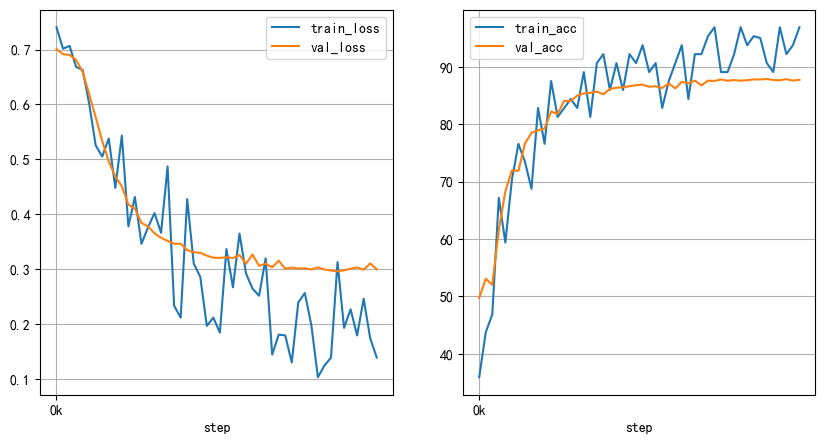

In [23]:
# 绘制学习曲线
plot_learning_curves(record_dict,sample_step=100)

In [24]:
# 在测试集上评估最终模型
test_acc, test_loss = evaluate_two_classification_model(model, test_dataloader, device, criterion)
print(f"测试集准确率: {test_acc:.2f}%, 测试集损失: {test_loss:.4f}")

测试集准确率: 88.13%, 测试集损失: 0.2949
